# Perceptron Binary Classification

This notebook demonstrates the `Perceptron` classifier implemented in the `jiayi_ml` package.

The perceptron is one of the earliest neural-network-style linear classifiers. It learns a linear decision boundary by updating its weights whenever it misclassifies a training example.

This example emphasizes:

1. Binary classification.
2. Linear separability.
3. Mistake-driven learning.
4. Decision boundary visualization.
5. The limitation of linear classifiers on nonlinearly separable data.
6. The relationship between perceptron and simple neural network ideas.


## 1. Problem Statement

The perceptron is a supervised binary classification algorithm.

Given labeled training data, the model learns a linear decision rule:

> Predict class 1 if the weighted sum of features is positive; otherwise predict class 0.

The perceptron updates its weights only when it makes a mistake. This makes it intuitive and historically important as a precursor to modern neural networks.

This notebook uses synthetic two-dimensional datasets so that the learned decision boundary can be visualized directly.


## Modeling Hypothesis

Because the first synthetic dataset is approximately linearly separable, the perceptron should learn an effective linear decision boundary.

The main hypothesis is:

> The perceptron will perform well on linearly separable data but will struggle on nonlinear moon-shaped data because it can only learn a linear boundary.

This comparison is intended to show both the historical value of the perceptron and its limitation relative to more flexible nonlinear classifiers.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.supervised import Perceptron
from jiayi_ml.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Generate a Linearly Separable Dataset

The first dataset is designed to be approximately linearly separable. This is the setting where the perceptron is expected to work well.

The dataset has:

- Two numeric features
- Two classes
- A linear class boundary with moderate noise

Because the data has only two features, we can visualize both the samples and the learned decision boundary.


In [2]:
X, y = make_classification(
    n_samples=250,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.02,
    random_state=438,
)

df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["target"] = y

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

df.head()


Feature matrix shape: (250, 2)
Target shape: (250,)


,feature_1,feature_2,target
0,-0.7634,2.4332,1
1,2.3552,1.7264,0
2,-1.4530,1.9408,1
3,-1.2528,2.2125,1
4,1.1441,1.7046,0


## 3. Exploratory Data Analysis

The class distribution and scatter plot help determine whether a linear classifier is reasonable.

The perceptron is most appropriate when the classes can be separated reasonably well by a straight line.


In [3]:
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = ["class 0", "class 1"]

class_counts_df = class_counts.to_frame(name="count")
class_counts_df["proportion"] = class_counts_df["count"] / class_counts_df["count"].sum()
class_counts_df


,count,proportion
class 0,127,0.508
class 1,123,0.492


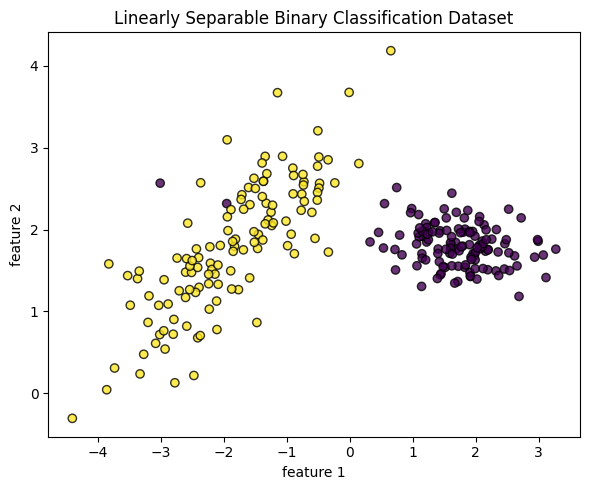

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", alpha=0.8)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Linearly Separable Binary Classification Dataset")
plt.tight_layout()
plt.show()


The scatter plot suggests that a linear decision boundary should perform reasonably well. This makes the dataset suitable for demonstrating the perceptron algorithm.


## 4. Train/Test Split and Standardization

The data is split into training and test sets using stratification.

The scaler is fit only on the training set and then applied to the test set. This avoids data leakage.

Feature scaling is important for perceptron training because the update size depends on feature magnitudes.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=438,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training set shape: (187, 2)
Test set shape: (63, 2)
Training class counts: [95 92]
Test class counts: [32 31]


## 5. Fit the Custom Perceptron

The model below uses the custom `Perceptron` implementation from `jiayi_ml`.

The perceptron updates its coefficients when a sample is misclassified. The `errors_` attribute records the number of mistakes in each training epoch.


In [6]:
model = Perceptron(
    learning_rate=0.05,
    max_iter=1000,
    fit_intercept=True,
    shuffle=True,
    random_state=438,
)

model.fit(X_train_scaled, y_train)

print("Number of epochs completed:", model.n_iter_)
print("Final number of errors in last epoch:", model.errors_[-1])
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Number of epochs completed: 1000
Final number of errors in last epoch: 5
Coefficients: [-0.229354    0.03466131]
Intercept: 0.05000000000000002


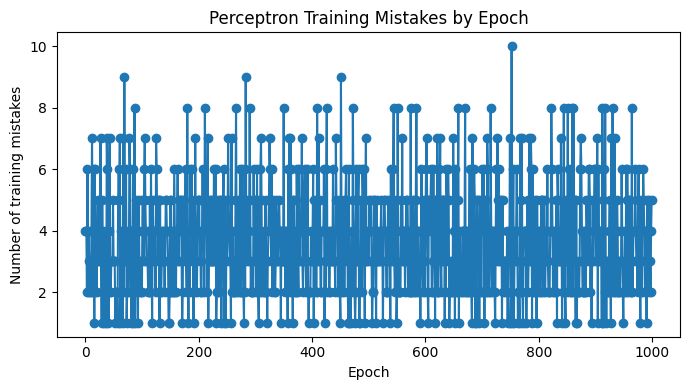

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Number of training mistakes")
plt.title("Perceptron Training Mistakes by Epoch")
plt.tight_layout()
plt.show()


A decreasing number of mistakes suggests that the perceptron is finding a useful separating boundary. If the data is perfectly linearly separable, the perceptron can eventually reach zero training mistakes. With noisy data, it may not reach zero mistakes.


## 6. Test-Set Evaluation

The model is evaluated on held-out test data using:

- Accuracy
- Precision
- Recall
- F1 score
- Confusion matrix


In [8]:
y_pred = model.predict(X_test_scaled)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, pos_label=1),
    "recall": recall_score(y_test, y_pred, pos_label=1),
    "f1": f1_score(y_test, y_pred, pos_label=1),
}

metrics_df = pd.DataFrame(metrics, index=["Perceptron"]).T
metrics_df


,Perceptron
accuracy,0.9683
precision,0.9394
recall,1.0000
f1,0.9688


In [9]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true class 0", "true class 1"],
    columns=["predicted class 0", "predicted class 1"],
)

cm_df


,predicted class 0,predicted class 1
true class 0,30,2
true class 1,0,31


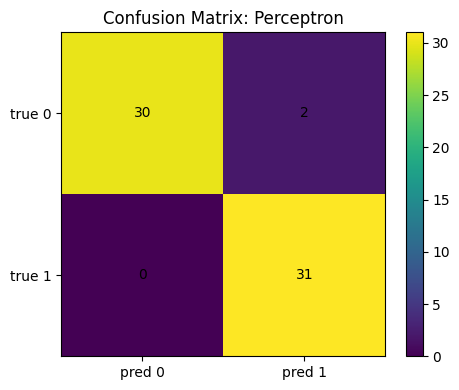

In [10]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix: Perceptron")
plt.colorbar()
plt.tight_layout()
plt.show()


The confusion matrix shows the two types of classification errors. Since this synthetic dataset has no clinical meaning, false positives and false negatives are interpreted symmetrically here.

In applied problems, the relative importance of each error type would depend on the domain.


## 7. Decision Boundary Visualization

Because the dataset has two features, we can visualize the learned perceptron decision boundary.

The model predicts class 1 when:

> coefficient_1 * x_1 + coefficient_2 * x_2 + intercept >= 0

This is a straight line in two dimensions.


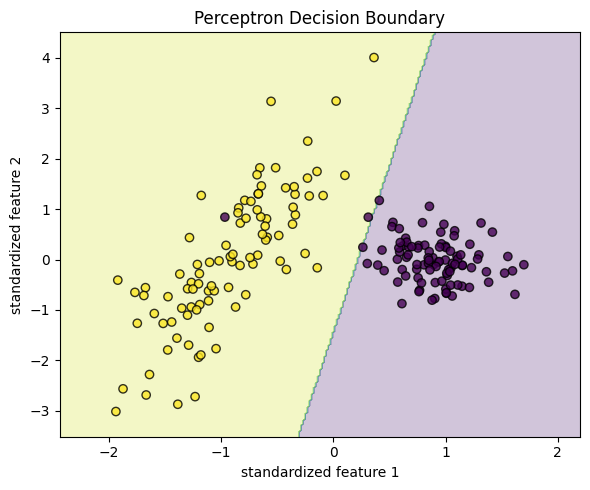

In [11]:
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_predictions = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_predictions, alpha=0.25)
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolors="k",
    alpha=0.8,
    label="training data",
)
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.title("Perceptron Decision Boundary")
plt.tight_layout()
plt.show()


The decision boundary is linear. This is appropriate for the first dataset because the classes were generated to be approximately linearly separable.


## 8. Comparison with a Nonlinearly Separable Dataset

The perceptron is limited to linear decision boundaries. To show this limitation, we now use a moon-shaped dataset.

The two classes form curved regions, so a straight line cannot separate them well.


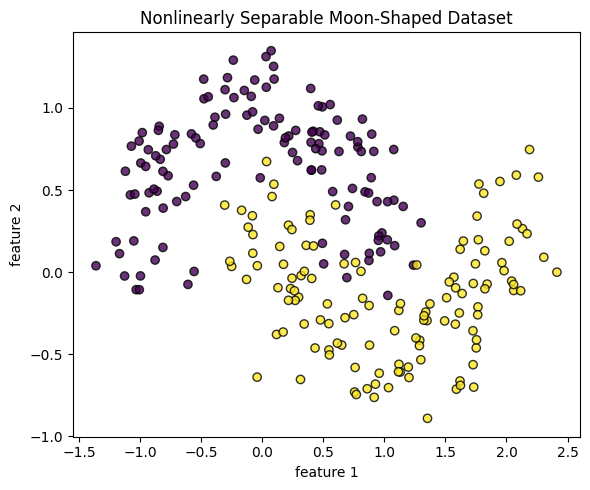

In [12]:
X_moons, y_moons = make_moons(
    n_samples=250,
    noise=0.20,
    random_state=438,
)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolors="k", alpha=0.8)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Nonlinearly Separable Moon-Shaped Dataset")
plt.tight_layout()
plt.show()


In [13]:
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.25,
    random_state=438,
    stratify=y_moons,
)

moon_scaler = StandardScaler()
X_moon_train_scaled = moon_scaler.fit_transform(X_moon_train)
X_moon_test_scaled = moon_scaler.transform(X_moon_test)

moon_model = Perceptron(
    learning_rate=0.05,
    max_iter=1000,
    fit_intercept=True,
    shuffle=True,
    random_state=438,
)

moon_model.fit(X_moon_train_scaled, y_moon_train)

moon_pred = moon_model.predict(X_moon_test_scaled)

moon_metrics = {
    "accuracy": accuracy_score(y_moon_test, moon_pred),
    "precision": precision_score(y_moon_test, moon_pred, pos_label=1),
    "recall": recall_score(y_moon_test, moon_pred, pos_label=1),
    "f1": f1_score(y_moon_test, moon_pred, pos_label=1),
}

pd.DataFrame(moon_metrics, index=["Perceptron on moons"]).T


,Perceptron on moons
accuracy,0.8095
precision,0.7714
recall,0.8710
f1,0.8182


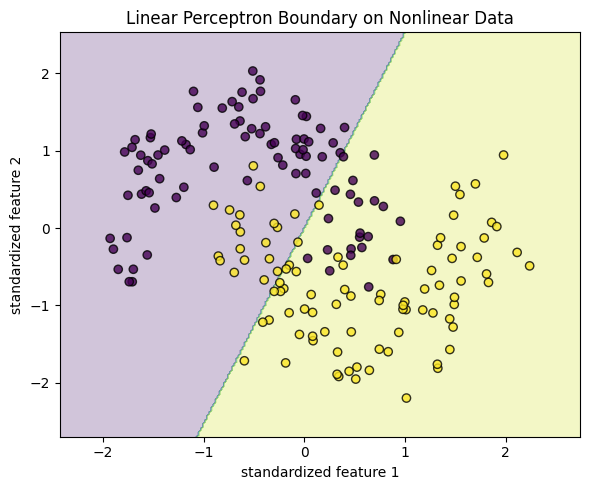

In [14]:
x_min, x_max = X_moon_train_scaled[:, 0].min() - 0.5, X_moon_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_moon_train_scaled[:, 1].min() - 0.5, X_moon_train_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_predictions = moon_model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_predictions, alpha=0.25)
plt.scatter(
    X_moon_train_scaled[:, 0],
    X_moon_train_scaled[:, 1],
    c=y_moon_train,
    edgecolors="k",
    alpha=0.8,
)
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.title("Linear Perceptron Boundary on Nonlinear Data")
plt.tight_layout()
plt.show()


The moon-shaped dataset illustrates a key limitation of the perceptron. Because the model is linear, it cannot naturally learn the curved boundary needed to separate the two classes.

This motivates more flexible models such as kernel methods, decision trees, random forests, or multilayer neural networks.


## 9. Interpretation

The perceptron is useful for understanding the foundation of linear classification and neural network training.

Its update rule is simple:

- If the sample is classified correctly, do nothing.
- If the sample is misclassified, update the weights in the direction of the correct class.

This mistake-driven learning rule is intuitive, but it works best when the data is linearly separable or nearly linearly separable.


## 10. Limitations

The perceptron has several important limitations:

1. It only learns a linear decision boundary.
2. It may not converge when data is not linearly separable.
3. It does not produce calibrated probabilities.
4. It is sensitive to feature scaling.
5. It can be sensitive to the order of training samples.
6. It is usually less flexible than modern classifiers.

Despite these limitations, it is historically important and conceptually useful because it connects linear classification with neural network learning.


## 11. Conclusion

This notebook demonstrated the custom `Perceptron` implementation from `jiayi_ml`.

Key takeaways:

- The perceptron is a binary linear classifier.
- It learns through mistake-driven weight updates.
- It performs well on approximately linearly separable data.
- Its decision boundary is easy to visualize in two dimensions.
- It struggles with nonlinear patterns such as moon-shaped data.
- It provides a useful conceptual bridge between classical linear models and neural networks.
